In [17]:
from convectio import Mitten

In [39]:
test1 = Mitten(([14]), ([2, 3, 4, 5, 6]), dirty_qc=True)

Configured IOP 14 with Transects: [2, 3, 4, 5, 6]
QC: Dropped 11880 points from UNL.CoMeTalpha.20240721.1345.L2_2024.p2.f1.rh2.ts2.tf2.w4.nc
Success! Loaded 10005 time steps.
Transects available: ['IOP14_T02_w' 'IOP14_T03_e' 'IOP14_T04_w' 'IOP14_T05_e' 'IOP14_T06_w']


In [40]:
test = test1.extract_tr()
t = test1.transect_dict()

In [41]:
from convectio import rel_distance

ds = rel_distance(test, t)
ds

<xarray.Dataset> Size: 961kB
Dimensions:       (time: 10005, ls_distance: 32, fr_distance: 10005)
Coordinates:
  * time          (time) datetime64[ns] 80kB 2024-07-21T14:33:00 ... 2024-07-...
    transect_id   (time) object 80kB 'IOP14_T02_w' ... 'IOP14_T06_w'
  * ls_distance   (ls_distance) float64 256B 46.97 46.92 46.86 ... 46.2 46.3
  * fr_distance   (fr_distance) float64 80kB 42.48 42.45 42.43 ... -2.684 -2.756
Data variables: (12/17)
    alt           (time) float32 40kB 235.3 234.1 233.0 ... 195.9 195.8 195.7
    lat           (time) float32 40kB 42.75 42.75 42.75 ... 42.71 42.71 42.71
    lon           (time) float32 40kB -85.79 -85.79 -85.79 ... -86.19 -86.19
    fast_temp     (time) float32 40kB 296.3 296.2 296.3 ... 297.3 297.4 297.3
    slow_temp     (time) float32 40kB 296.1 296.1 296.1 ... 297.6 297.6 297.6
    pressure      (time) float32 40kB 9.921e+04 9.921e+04 ... 9.959e+04
    ...            ...
    dewpoint      (time) float32 40kB 17.23 17.23 17.23 ... 19.21 19.25 19.39
    mixing_ratio  (time) float32 40kB 0.01258 0.01258 ... 0.01426 0.01438
    theta         (time) float32 40kB 296.9 296.9 296.9 ... 297.6 297.7 297.7
    theta_v       (time) float32 40kB 299.2 299.2 299.2 ... 300.2 300.3 300.3
    theta_e       (time) float32 40kB 332.7 332.7 332.7 ... 338.0 338.2 338.5
    error_flag    (time) object 80kB 'g00-p02-tf00-ts00-rh00-f01-w00-a00' ......
Attributes:
    title:        2024-07-21 Combined Mesonet and Tracker synchronized data file
    institution:  Central Michigan University
    source:       Combined Mesonet and Tracker alpha (CoMeT-alpha)
    comment:      PI Contact Info: Jason Keeler (keele1j@cmich.edu)
    description:  All selected transects.

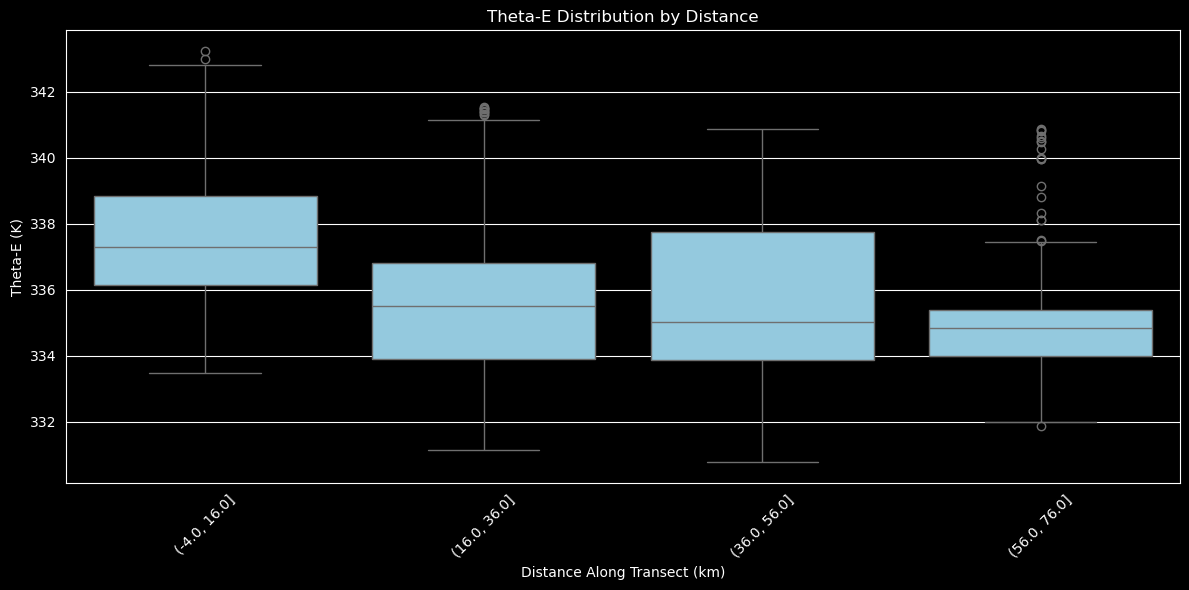

In [43]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def bin_dataset_variable(ds, bin_var, data_var, bin_step):
    """
    Bins a data variable by a binning variable (coordinate or other variable).
    Handles the messy case where dimensions have different names but same size.
    """

    # 1. Grab the raw arrays
    # We use .values.flatten() to nuke the dimension labels.
    # This effectively tells Xarray to shut up about dimension mismatches.
    x_data = ds[bin_var].values.flatten()
    y_data = ds[data_var].values.flatten()

    # 2. Sanity Check
    # If these aren't the same length, the plot is going to be garbage.
    if x_data.size != y_data.size:
        raise ValueError(f"Size mismatch: {bin_var} has {x_data.size} points, "
                         f"but {data_var} has {y_data.size}. "
                         "Cannot bin if they don't line up.")

    # 3. Create the DataFrame manually
    df = pd.DataFrame({
        bin_var: x_data,
        data_var: y_data
    })

    # Drop NaNs immediately or the binning will throw a fit
    df = df.dropna()

    # 4. Binning Logic
    # Calculate min/max and create edges
    min_val = np.floor(df[bin_var].min())
    max_val = np.ceil(df[bin_var].max())

    # Create the bins (using m-nth kilometer step from args)
    bins = np.arange(min_val, max_val + bin_step, bin_step)

    # Cut the data
    df['bin'] = pd.cut(df[bin_var], bins=bins)

    # 5. Return the clean dataframe ready for plotting
    return df

# --- Usage Example ---

# Run the function
# This will work even though 'fr_distance' and 'theta' are on different dims
df_binned = bin_dataset_variable(ds, bin_var='fr_distance', data_var='theta_e', bin_step=20) # 10 km steps

# Plot the damn thing
plt.figure(figsize=(12, 6))
sns.boxplot(x='bin', y='theta_e', data=df_binned, color='skyblue')

plt.xticks(rotation=45)
plt.xlabel("Distance Along Transect (km)")
plt.ylabel("Theta-E (K)")
plt.title("Theta-E Distribution by Distance")
plt.tight_layout()
plt.show()

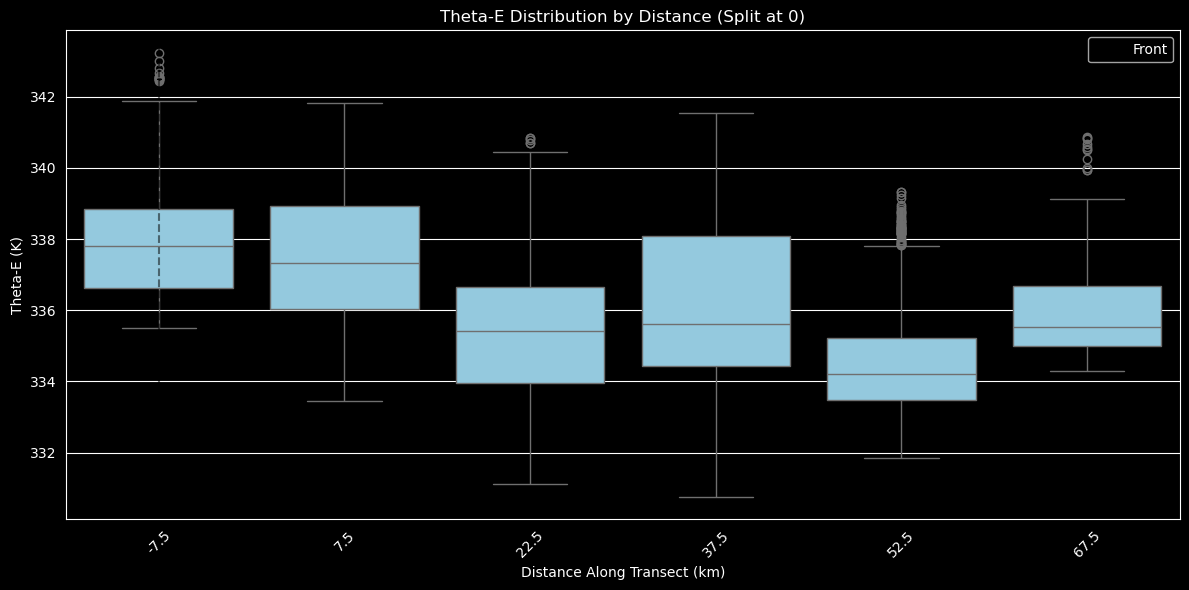

In [46]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def bin_dataset_variable(ds, bin_var, data_var, bin_step):
    """
    Bins a data variable by a binning variable with a hard split at 0.
    Ensures negative values stay in negative bins and positives in positive bins.
    """

    # 1. Grab the raw arrays
    # .values.flatten() ignores dimension names and just grabs the data
    x_data = ds[bin_var].values.flatten()
    y_data = ds[data_var].values.flatten()

    # 2. Sanity Check
    if x_data.size != y_data.size:
        raise ValueError(f"Size mismatch: {bin_var} has {x_data.size} points, "
                         f"but {data_var} has {y_data.size}. "
                         "Cannot bin if they don't line up.")

    # 3. Create the DataFrame manually & Drop NaNs
    df = pd.DataFrame({
        bin_var: x_data,
        data_var: y_data
    }).dropna()

    # --- 4. NEW BINNING LOGIC (Hard Zero Split) ---

    # Calculate the maximum reach of the data to know how far to generate bins
    # We use the absolute max to ensure we cover both sides equally if needed
    min_val = np.floor(df[bin_var].min())
    max_val = np.ceil(df[bin_var].max())

    # Generate Positive Edges (0, 10, 20, ...)
    # We go slightly past max_val to ensure the last data point is caught
    pos_bins = np.arange(0, max_val + bin_step, bin_step)

    # Generate Negative Edges (0, -10, -20, ...)
    # We go slightly past min_val (in the negative direction)
    neg_bins = np.arange(0, min_val - bin_step, -bin_step)

    # Combine them into one sorted array of edges
    # np.unique sorts them and removes the duplicate '0'
    bins = np.unique(np.concatenate([neg_bins, pos_bins]))

    # Cut the data
    # right=False means bins are [0, 10), [10, 20).
    # This keeps 0.0 exactly in the first positive bin.
    df['bin'] = pd.cut(df[bin_var], bins=bins, right=False)

    # Calculate a center point for cleaner plotting (e.g., -15, -5, 5, 15)
    df['bin_center'] = df['bin'].apply(lambda x: x.mid)

    # 5. Return the clean dataframe ready for plotting
    return df

# --- Usage Example ---

# Run the function
# Using 20km steps as requested
df_binned = bin_dataset_variable(ds, bin_var='fr_distance', data_var='theta_e', bin_step=15)

# Plot
plt.figure(figsize=(12, 6))

# UPDATED: Use 'bin_center' for the x-axis so you get numbers, not messy interval strings
sns.boxplot(x='bin_center', y='theta_e', data=df_binned, color='skyblue')

# Add a line to show the front location
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5, label='Front')

plt.xticks(rotation=45)
plt.xlabel("Distance Along Transect (km)")
plt.ylabel("Theta-E (K)")
plt.title("Theta-E Distribution by Distance (Split at 0)")
plt.legend()
plt.tight_layout()
plt.show()

<xarray.DataArray 'fr_distance' ()> Size: 8B
array(63.00362506)